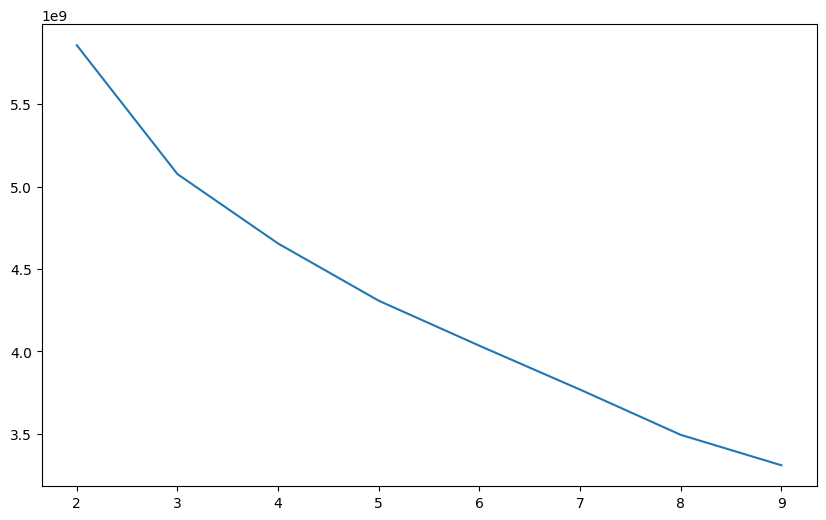

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [8]:
import numpy as np

fruits = np.load(r'C:\Machine\fruits_300.npy')

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

fruits_2ax = fruits.reshape(-1, 100*100)

try:
    inertia = []
    for cluster in range(2, 10, 1):
        km = KMeans(n_clusters=cluster, random_state=42)
        km.fit(fruits_2ax)
        inertia.append(km.inertia_)
    
    plt.figure(figsize=(10,6))
    plt.plot(range(2, 10, 1), inertia)
    plt.show()
except Exception as e:
    print(e)

km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_2ax)
print(np.unique(km.labels_, return_counts=True))

C:\Users\박중현\AppData\Local\Temp\ipykernel_13956\757868036.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


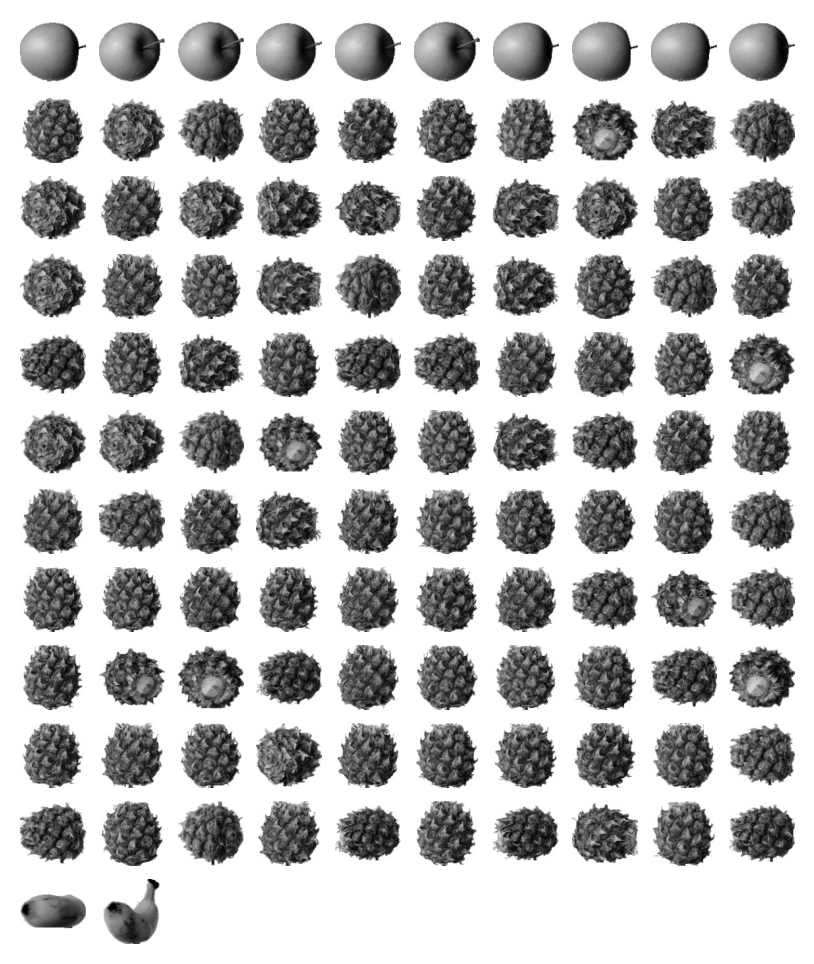

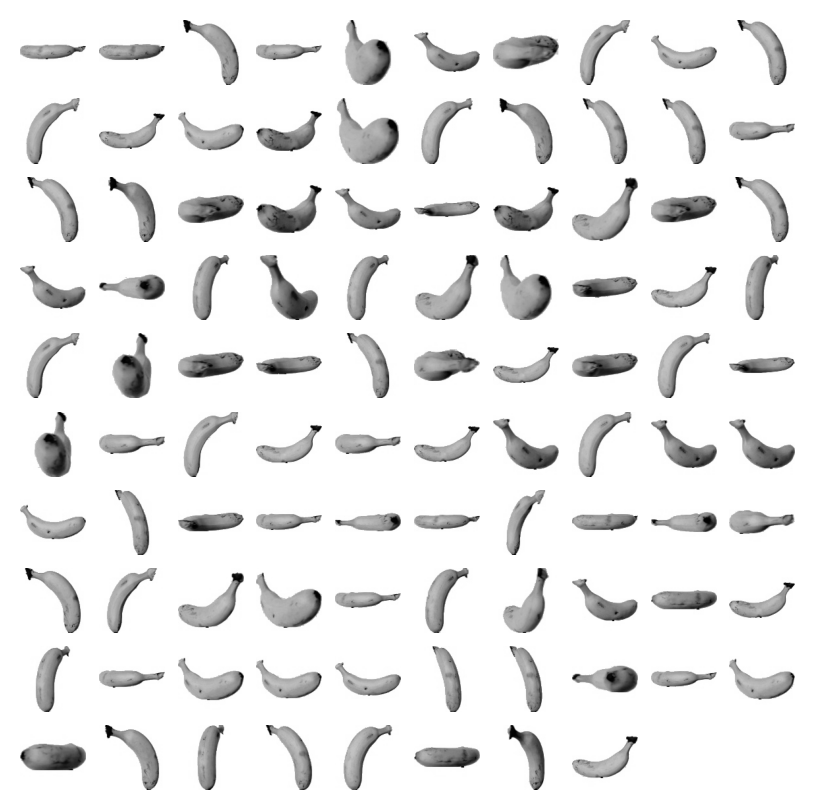

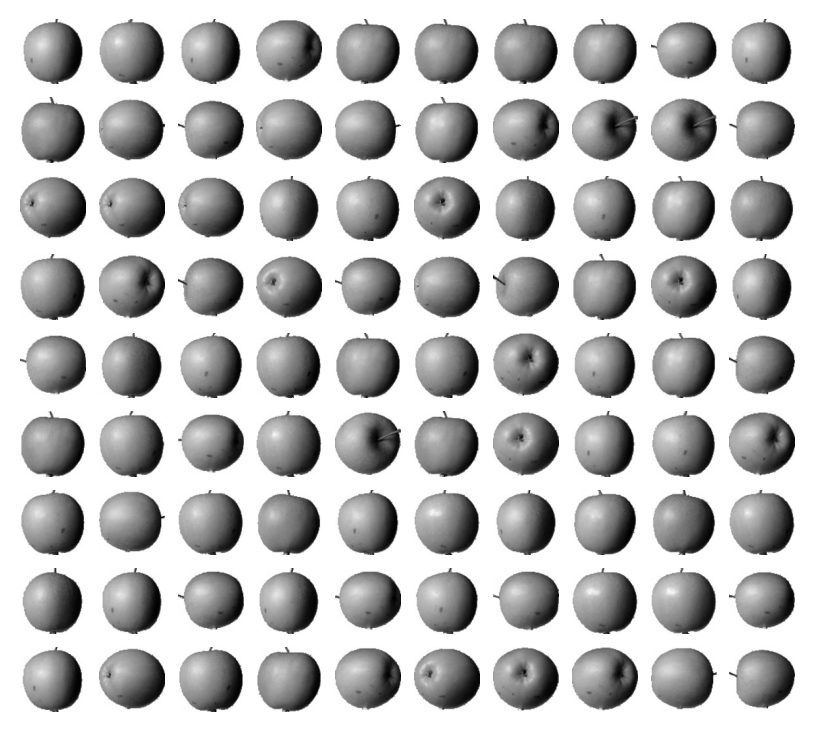

In [ ]:
def draw_fruits(fruits_arr, ratio=0.5):
    
    n = len(fruits_arr)
    col = n if n < 10 else 10
    idx = int(np.ceil(n/10))
    
    fig, axs = plt.subplots(idx, col, figsize=(ratio*col, ratio*idx), dpi=200, squeeze=False)
    num=0
    for i in range(idx):
        for j in range(col):
            if num < n:
                axs[i, j].imshow(fruits_arr[10*i+j], cmap='gray_r')
            axs[i, j].axis('off')
            num=num+1
    fig.show()

for n in [0, 1, 2]:
    draw_fruits(fruits[km.labels_==n])
    print('\n')
    
#0=pineapple, 1=banana, 2=apple

(3, 10000)
4
[[3400.24197319 8837.37750892 5279.33763699]]
[0]
16917579.43977306
[[1.         1.         1.         ... 1.         1.         1.        ]
 [1.10204082 1.07142857 1.10204082 ... 1.         1.         1.        ]
 [1.01111111 1.01111111 1.01111111 ... 1.         1.         1.        ]]


C:\Users\박중현\AppData\Local\Temp\ipykernel_13956\757868036.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


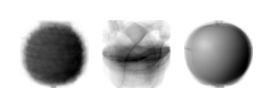

In [23]:
print(km.cluster_centers_.shape)
print(km.n_iter_)

print(km.transform(fruits_2ax[100:101]))
print(km.predict(fruits_2ax[100:101]))
print(km.inertia_/len(fruits_2ax))
print(km.cluster_centers_)

draw_fruits(km.cluster_centers_.reshape(-1, 100, 100))

[[-9.24490195e-06 -5.10601298e-06 -8.91640398e-06 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [ 1.69701615e-05  1.13551049e-05  1.82152565e-05 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.65220437e-05 -2.08401750e-05 -2.89870100e-05 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 ...
 [-4.07017206e-05 -9.73635267e-07 -4.70935284e-05 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [ 6.61931510e-05  9.80954156e-05  1.29058217e-04 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-5.56484103e-05  8.98689653e-05  1.03358519e-04 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]
50


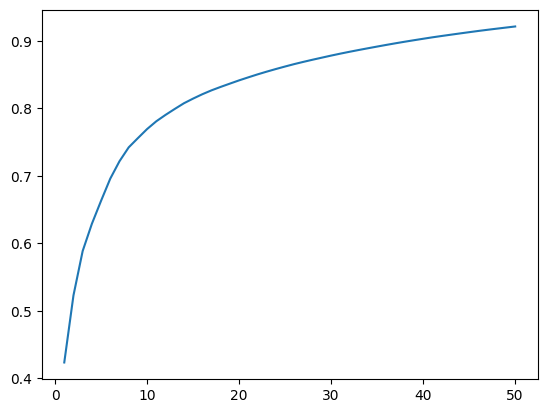

In [51]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
pca.fit(fruits_2ax)
fruits_pca = pca.transform(fruits_2ax)

print(pca.components_)
print(pca.n_components)

a = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, 51), a)
plt.show()



In [52]:
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
lr = LogisticRegression()
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fruits_target = [0]*100 + [1]*100 + [2]*100
scores = cross_validate(lr, fruits_2ax, fruits_target, cv=splitter, return_train_score=True)
scores2 = cross_validate(lr, fruits_pca, fruits_target, cv=splitter, return_train_score=True)
print(f"원데이터: {np.mean(scores['train_score'])}, {np.mean(scores['test_score'])}")
print(f"pca 데이터: {np.mean(scores2['train_score'])}, {np.mean(scores2['test_score'])}")
print(f"시간단축: {np.mean(scores['fit_time'])/np.mean(scores2['fit_time'])}")

pca = PCA(n_components=0.5)
pca.fit(fruits_2ax)
print(pca.n_components_)

(300, 10000)
원데이터: 1.0, 0.9966666666666667
pca 데이터: 1.0, 0.9966666666666667
시간단축: 25.659576887517737
2


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2]


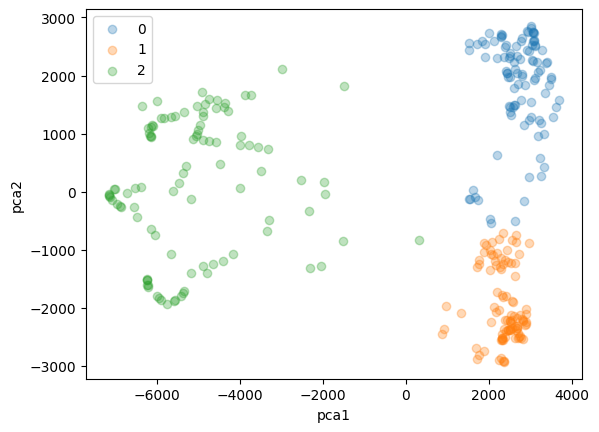

In [ ]:
lr.fit(fruits_pca, fruits_target)
print(lr.predict(fruits_pca))

for clas in [0, 1, 2]:
    idx = lr.predict(fruits_pca) == clas
    plt.scatter(fruits_pca[idx, 0], fruits_pca[idx, 1], alpha=0.3, label=clas)
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.legend()
plt.show()


    

In [62]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 60

academic = np.random.normal(0, 1, n)      # 학업 성향
wellbeing = np.random.normal(0, 1, n)     # 건강/생활 균형
distraction = np.random.normal(0, 1, n)   # 산만함/여가 성향

df = pd.DataFrame({
    'study_hours':      5 + 1.2*academic - 0.4*distraction + np.random.normal(0, 0.5, n),
    'attendance_rate': 80 + 8*academic - 2*distraction + np.random.normal(0, 2, n),
    'assignment_score': 75 + 7*academic - 1.5*distraction + np.random.normal(0, 2, n),
    'sleep_hours':      6.5 + 0.8*wellbeing - 0.3*academic + np.random.normal(0, 0.4, n),
    'exercise_hours':   1.5 + 0.9*wellbeing - 0.2*distraction + np.random.normal(0, 0.3, n),
    'leisure_hours':    3 + 0.8*distraction - 0.4*academic + 0.3*wellbeing + np.random.normal(0, 0.4, n),
    'phone_hours':      4 + 1.0*distraction - 0.5*academic + np.random.normal(0, 0.5, n),
    'stress_score':    50 + 6*academic - 2*wellbeing + 1.5*distraction + np.random.normal(0, 2, n)
})

df.head()

df.describe()
df.corr().round(2)

,study_hours,attendance_rate,assignment_score,sleep_hours,exercise_hours,leisure_hours,phone_hours,stress_score
study_hours,1.00,0.86,0.91,-0.31,0.10,-0.49,-0.43,0.70
attendance_rate,0.86,1.00,0.94,-0.32,0.10,-0.41,-0.37,0.75
assignment_score,0.91,0.94,1.00,-0.32,0.07,-0.47,-0.43,0.77
sleep_hours,-0.31,-0.32,-0.32,1.00,0.79,0.39,0.18,-0.54
exercise_hours,0.10,0.10,0.07,0.79,1.00,0.22,-0.00,-0.24
leisure_hours,-0.49,-0.41,-0.47,0.39,0.22,1.00,0.84,-0.15
phone_hours,-0.43,-0.37,-0.43,0.18,-0.00,0.84,1.00,0.01
stress_score,0.70,0.75,0.77,-0.54,-0.24,-0.15,0.01,1.00


      explained_variance_ratio  cumulative_ratio
pca1                  0.523216          0.523216
pca2                  0.221381          0.744597
pca3                  0.187520          0.932118
pca4                  0.018876          0.950994
pca5                  0.017104          0.968098
pca6                  0.014945          0.983044
pca7                  0.012305          0.995348
pca8                  0.004652          1.000000


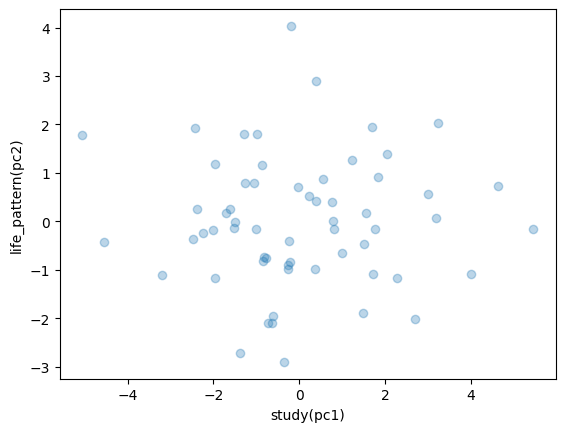

,study_hours,attendance_rate,assignment_score,sleep_hours,exercise_hours,leisure_hours,phone_hours,stress_score
pca1,0.443074,0.441393,0.457158,-0.273037,-0.080681,-0.320204,-0.271431,0.377625
pca2,0.196388,0.195725,0.187452,0.587053,0.719871,0.083523,-0.089116,-0.101102
pca3,0.085969,0.165687,0.129002,-0.046055,0.013635,0.568251,0.640714,0.461287
pca4,0.584580,-0.515862,-0.133924,0.216678,-0.048249,-0.414171,0.366596,0.137874
pca5,-0.417599,0.068800,0.225871,0.653797,-0.421134,-0.232600,0.015457,0.332737
pca6,0.344170,-0.343091,0.110005,0.201499,-0.316516,0.581356,-0.518758,0.062179
pca7,-0.276308,-0.350281,-0.197373,-0.162245,0.420538,-0.057221,-0.295206,0.684401
pca8,-0.216344,-0.477657,0.786903,-0.193323,0.135551,-0.026375,0.130313,-0.179995


In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x = df.copy()
ss = StandardScaler()
x_scaled = ss.fit_transform(x)
pca =PCA(n_components=len(x.columns))
x_pca = pca.fit_transform(x_scaled)

explained_var = pd.DataFrame({'explained_variance_ratio': pca.explained_variance_ratio_,
                              'cumulative_ratio': pca.explained_variance_ratio_.cumsum()},
                             index = [f'pca{i}' for i in range(1, len(x.columns)+1)])
print(explained_var)

leading = pd.DataFrame(pca.components_,
                       columns=[x.columns],
                       index=[f'pca{i}' for i in range(1, len(x.columns)+1)])
leading.loc['pca1'].abs().sort_values(ascending=False)
leading.loc['pca2'].abs().sort_values(ascending=False)



plt.scatter(x_pca[:, 0], x_pca[:, 1], alpha=0.3)
plt.xlabel('study(pc1)')
plt.ylabel('life_pattern(pc2)')
plt.show()

leading

In [1]:
from sklearn.cluster import KMeans
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_scaled)

inertia = []
for n in range(2, 15):
    km = KMeans(n_clusters=n, random_state=42)
    km.fit(x_pca)
    inertia.append(km.inertia_)
plt.plot(inertia)
plt.show()

km = KMeans(n_clusters=4, random_state=42)
km.fit(x_pca)
np.unique(km.labels_, return_counts=True)

for label in np.unique(km.labels_):
    data = x_pca[km.labels_ == label]
    plt.scatter(data[:, 0], data[:, 1], alpha=0.3, label=label)
plt.xlabel('study')
plt.ylabel('life_balance')
plt.legend()
plt.show()
    


NameError: name 'PCA' is not defined

['study_hours', 'attendance_rate', 'assignment_score', 'phone_hours', 'sleep_hours']
